# Covid 19 Data Analysis

In [1]:
# Importing all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading of dataset

In [2]:
# Readind the .csv data set to dataframe
df = pd.read_csv("covid_19_dataset.csv")
df.head(5)

,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,NaN,0,0.0,0
1,2020-01-23,Afghanistan,NaN,0,0.0,0
2,2020-01-24,Afghanistan,NaN,0,0.0,0
3,2020-01-25,Afghanistan,NaN,0,0.0,0
4,2020-01-26,Afghanistan,NaN,0,0.0,0


In [3]:
# Information on dataset columns and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231744 entries, 0 to 231743
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date            231744 non-null  object 
 1   Country/Region  231744 non-null  object 
 2   Province/State  72624 non-null   object 
 3   Confirmed       231744 non-null  int64  
 4   Recovered       218688 non-null  float64
 5   Deaths          231744 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 10.6+ MB


In [4]:
# Shape of the dataset
df.shape

(231744, 6)

## Data Cleaning

In [5]:
# null Values percentage
df.isnull().mean()

Date              0.000000
Country/Region    0.000000
Province/State    0.686620
Confirmed         0.000000
Recovered         0.056338
Deaths            0.000000
dtype: float64

In [6]:
# As province/State Column has more than 50 % data with null values its better to drop it
df = df.drop(columns=["Province/State"])

In [7]:
# Simplifying the large name of column to short and meaning full name
df = df.rename(columns={"Country/Region": "Country"})

In [8]:
# checking the datatypes of columns in dataset
df.dtypes

Date          object
Country       object
Confirmed      int64
Recovered    float64
Deaths         int64
dtype: object

In [9]:
# Date column should be in datetime datatype instead of object type
# Changing the data type of date column
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date         datetime64[ns]
Country              object
Confirmed             int64
Recovered           float64
Deaths                int64
dtype: object

In [10]:
# Checking nulls for "Recovered" Column in dataset
df["Recovered"].isna().mean()

np.float64(0.056338028169014086)

In [11]:
# "Recovered" Column in dataset contains 5.6% of null values
# Hence it is better to fill the nulls with median data instead of droping the column
df["Recovered"] = df["Recovered"].fillna(
    df.groupby(["Country", "Date"])["Recovered"].transform("median")
)
# Step 1 filling the data by Country and Date wise aggregation median
df["Recovered"].isna().mean()

np.float64(0.056338028169014086)

In [12]:
# after filling the data according to Country and Date grouped fails then we will fill proceed with step 2
df["Recovered"] = df["Recovered"].fillna(
    df.groupby("Country")["Recovered"].transform("median")
)
# Step 2 filling the data by Country wise aggregation median
df["Recovered"].isna().mean()

np.float64(0.056338028169014086)

In [13]:
# Step 3: check the null rows and 
# Filter rows where Recovered is still null
null_rows = df[df["Recovered"].isna()]

print("Number of rows still null:", null_rows.shape[0])
print(null_rows.head(10))  # show first 10 problematic rows

Number of rows still null: 13056
            Date Country  Confirmed  Recovered  Deaths
32640 2020-01-22  Canada          0        NaN       0
32641 2020-01-23  Canada          0        NaN       0
32642 2020-01-24  Canada          0        NaN       0
32643 2020-01-25  Canada          0        NaN       0
32644 2020-01-26  Canada          0        NaN       0
32645 2020-01-27  Canada          0        NaN       0
32646 2020-01-28  Canada          0        NaN       0
32647 2020-01-29  Canada          0        NaN       0
32648 2020-01-30  Canada          0        NaN       0
32649 2020-01-31  Canada          0        NaN       0


In [14]:
# To check the unique contries where null values are present
# Check the Confirmed and Death columns Vaules
print("Country:", null_rows["Country"].unique())
print("Confirmed Unique nos:", null_rows["Confirmed"].value_counts())
print("Deaths Unique nos:", null_rows["Deaths"].value_counts())

Country: ['Canada']
Confirmed Unique nos: Confirmed
0       1955
13      1275
5        216
15       104
11        97
        ... 
3876       1
3821       1
3798       1
3786       1
3770       1
Name: count, Length: 5424, dtype: int64
Deaths Unique nos: Deaths
0        4228
1        1091
4         486
7         240
3         215
         ... 
764         1
751         1
747         1
746         1
11724       1
Name: count, Length: 2671, dtype: int64


In [15]:
# Step 1: Compute date-wise median of Recovered
date_median = df.groupby("Date")["Recovered"].transform("median")

# Step 2: Fill Canada’s nulls with the date-wise median
mask = (df["Country"] == "Canada") & (df["Recovered"].isna())
df.loc[mask, "Recovered"] = date_median[mask]

# Optional: convert to Int64 for clean counts
df["Recovered"] = df["Recovered"].astype("int64")
df[df["Country"] == "Canada"].tail(25)

,Date,Country,Confirmed,Recovered,Deaths
45671,2022-03-23,Canada,3692,0,24
45672,2022-03-24,Canada,3705,0,24
45673,2022-03-25,Canada,3721,0,24
45674,2022-03-26,Canada,3721,0,24
45675,2022-03-27,Canada,3721,0,24
45676,2022-03-28,Canada,3770,0,24
45677,2022-03-29,Canada,3786,0,24
45678,2022-03-30,Canada,3798,0,24
45679,2022-03-31,Canada,3821,0,24
45680,2022-04-01,Canada,3844,0,24


In [16]:
df.isnull().mean()
# No null value present

Date         0.0
Country      0.0
Confirmed    0.0
Recovered    0.0
Deaths       0.0
dtype: float64

In [17]:
df.info()
# No Data type error

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231744 entries, 0 to 231743
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       231744 non-null  datetime64[ns]
 1   Country    231744 non-null  object        
 2   Confirmed  231744 non-null  int64         
 3   Recovered  231744 non-null  int64         
 4   Deaths     231744 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 8.8+ MB


In [18]:
# Group the data based on Date and Country as it was divided by provinces/state wise 
df = df.groupby(["Country", "Date"]).sum().reset_index()

In [19]:
df.shape

(161568, 5)

## Generating New Informative Columns 

### Recovery and Mortality Rate

In [20]:
# Recovery rate = Recovered / Confirmed
df["Recovery_Rate"] = np.where(df["Confirmed"] > 0,
                               df["Recovered"]*100/df["Confirmed"], 0)

In [21]:
# Mortality rate = Deaths / Confirmed
df["Mortality_Rate"] = np.where(df["Confirmed"] > 0,
                               df["Deaths"]*100/df["Confirmed"], 0)

In [22]:
df

,Country,Date,Confirmed,Recovered,Deaths,Recovery_Rate,Mortality_Rate
0,Afghanistan,2020-01-22,0,0,0,0.0,0.000000
1,Afghanistan,2020-01-23,0,0,0,0.0,0.000000
2,Afghanistan,2020-01-24,0,0,0,0.0,0.000000
3,Afghanistan,2020-01-25,0,0,0,0.0,0.000000
4,Afghanistan,2020-01-26,0,0,0,0.0,0.000000
...,...,...,...,...,...,...,...
161563,Zimbabwe,2022-04-12,247094,0,5460,0.0,2.209685
161564,Zimbabwe,2022-04-13,247160,0,5460,0.0,2.209095
161565,Zimbabwe,2022-04-14,247208,0,5462,0.0,2.209475
161566,Zimbabwe,2022-04-15,247237,0,5462,0.0,2.209216


### Growth Rates (daily differences)

In [23]:
# Daily new confirmed cases
df["New_Confirmed"] = df.groupby("Country")["Confirmed"].diff().fillna(0).apply(lambda x: x if x > 0 else 0)

In [24]:
# Daily new recovered cases
df["New_Recovered"] = df.groupby("Country")["Recovered"].diff().fillna(0).apply(lambda x: x if x > 0 else 0)

In [25]:
# Daily new deaths
df["New_Deaths"] = df.groupby("Country")["Deaths"].diff().fillna(0).apply(lambda x: x if x > 0 else 0)

In [26]:
df

,Country,Date,Confirmed,Recovered,Deaths,Recovery_Rate,Mortality_Rate,New_Confirmed,New_Recovered,New_Deaths
0,Afghanistan,2020-01-22,0,0,0,0.0,0.000000,0.0,0.0,0.0
1,Afghanistan,2020-01-23,0,0,0,0.0,0.000000,0.0,0.0,0.0
2,Afghanistan,2020-01-24,0,0,0,0.0,0.000000,0.0,0.0,0.0
3,Afghanistan,2020-01-25,0,0,0,0.0,0.000000,0.0,0.0,0.0
4,Afghanistan,2020-01-26,0,0,0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
161563,Zimbabwe,2022-04-12,247094,0,5460,0.0,2.209685,84.0,0.0,0.0
161564,Zimbabwe,2022-04-13,247160,0,5460,0.0,2.209095,66.0,0.0,0.0
161565,Zimbabwe,2022-04-14,247208,0,5462,0.0,2.209475,48.0,0.0,2.0
161566,Zimbabwe,2022-04-15,247237,0,5462,0.0,2.209216,29.0,0.0,0.0


### Active Cases Estimate

In [27]:
df["Active_Cases"] = df["Confirmed"] - (df["Recovered"] + df["Deaths"])

In [28]:
df

,Country,Date,Confirmed,Recovered,Deaths,Recovery_Rate,Mortality_Rate,New_Confirmed,New_Recovered,New_Deaths,Active_Cases
0,Afghanistan,2020-01-22,0,0,0,0.0,0.000000,0.0,0.0,0.0,0
1,Afghanistan,2020-01-23,0,0,0,0.0,0.000000,0.0,0.0,0.0,0
2,Afghanistan,2020-01-24,0,0,0,0.0,0.000000,0.0,0.0,0.0,0
3,Afghanistan,2020-01-25,0,0,0,0.0,0.000000,0.0,0.0,0.0,0
4,Afghanistan,2020-01-26,0,0,0,0.0,0.000000,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
161563,Zimbabwe,2022-04-12,247094,0,5460,0.0,2.209685,84.0,0.0,0.0,241634
161564,Zimbabwe,2022-04-13,247160,0,5460,0.0,2.209095,66.0,0.0,0.0,241700
161565,Zimbabwe,2022-04-14,247208,0,5462,0.0,2.209475,48.0,0.0,2.0,241746
161566,Zimbabwe,2022-04-15,247237,0,5462,0.0,2.209216,29.0,0.0,0.0,241775


### Growth Rate Confirmed

In [29]:
df["Growth_Rate_Confirmed"] = np.where(df["Confirmed"].shift(1) > 0,
                                     (df["Confirmed"] - df["Confirmed"].shift(1)) / df["Confirmed"].shift(1),
                                     0)

In [30]:
df

,Country,Date,Confirmed,Recovered,Deaths,Recovery_Rate,Mortality_Rate,New_Confirmed,New_Recovered,New_Deaths,Active_Cases,Growth_Rate_Confirmed
0,Afghanistan,2020-01-22,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000
1,Afghanistan,2020-01-23,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000
2,Afghanistan,2020-01-24,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000
3,Afghanistan,2020-01-25,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000
4,Afghanistan,2020-01-26,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
161563,Zimbabwe,2022-04-12,247094,0,5460,0.0,2.209685,84.0,0.0,0.0,241634,0.000340
161564,Zimbabwe,2022-04-13,247160,0,5460,0.0,2.209095,66.0,0.0,0.0,241700,0.000267
161565,Zimbabwe,2022-04-14,247208,0,5462,0.0,2.209475,48.0,0.0,2.0,241746,0.000194
161566,Zimbabwe,2022-04-15,247237,0,5462,0.0,2.209216,29.0,0.0,0.0,241775,0.000117


### Death - Recovery Ratio

In [31]:
df["Death_Recovery_Ratio"] = np.where(df["Recovered"] > 0,
                                      df["Deaths"] / df["Recovered"],
                                      0)

In [32]:
df

,Country,Date,Confirmed,Recovered,Deaths,Recovery_Rate,Mortality_Rate,New_Confirmed,New_Recovered,New_Deaths,Active_Cases,Growth_Rate_Confirmed,Death_Recovery_Ratio
0,Afghanistan,2020-01-22,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0
1,Afghanistan,2020-01-23,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0
2,Afghanistan,2020-01-24,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0
3,Afghanistan,2020-01-25,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0
4,Afghanistan,2020-01-26,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
161563,Zimbabwe,2022-04-12,247094,0,5460,0.0,2.209685,84.0,0.0,0.0,241634,0.000340,0.0
161564,Zimbabwe,2022-04-13,247160,0,5460,0.0,2.209095,66.0,0.0,0.0,241700,0.000267,0.0
161565,Zimbabwe,2022-04-14,247208,0,5462,0.0,2.209475,48.0,0.0,2.0,241746,0.000194,0.0
161566,Zimbabwe,2022-04-15,247237,0,5462,0.0,2.209216,29.0,0.0,0.0,241775,0.000117,0.0


### Rolling Confirmed, Recovery and Death Averages

In [33]:
# 7-day rolling average for new confirmed
df["New_Confirmed_Avg_7Days"] = df["New_Confirmed"].rolling(window=7, min_periods=1).mean()

In [34]:
# 7-day rolling average for new confirmed
df["New_Recovered_Avg_7Days"] = df["New_Recovered"].rolling(window=7, min_periods=1).mean()

In [35]:
# 7-day rolling average for new deaths
df["New_Deaths_Avg_7Days"] = df["New_Deaths"].rolling(window=7, min_periods=1).mean()

In [36]:
df

,Country,Date,Confirmed,Recovered,Deaths,Recovery_Rate,Mortality_Rate,New_Confirmed,New_Recovered,New_Deaths,Active_Cases,Growth_Rate_Confirmed,Death_Recovery_Ratio,New_Confirmed_Avg_7Days,New_Recovered_Avg_7Days,New_Deaths_Avg_7Days
0,Afghanistan,2020-01-22,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000
1,Afghanistan,2020-01-23,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000
2,Afghanistan,2020-01-24,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000
3,Afghanistan,2020-01-25,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000
4,Afghanistan,2020-01-26,0,0,0,0.0,0.000000,0.0,0.0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161563,Zimbabwe,2022-04-12,247094,0,5460,0.0,2.209685,84.0,0.0,0.0,241634,0.000340,0.0,50.000000,0.0,1.285714
161564,Zimbabwe,2022-04-13,247160,0,5460,0.0,2.209095,66.0,0.0,0.0,241700,0.000267,0.0,51.000000,0.0,1.000000
161565,Zimbabwe,2022-04-14,247208,0,5462,0.0,2.209475,48.0,0.0,2.0,241746,0.000194,0.0,48.285714,0.0,1.000000
161566,Zimbabwe,2022-04-15,247237,0,5462,0.0,2.209216,29.0,0.0,0.0,241775,0.000117,0.0,44.571429,0.0,0.714286


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161568 entries, 0 to 161567
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Country                  161568 non-null  object        
 1   Date                     161568 non-null  datetime64[ns]
 2   Confirmed                161568 non-null  int64         
 3   Recovered                161568 non-null  int64         
 4   Deaths                   161568 non-null  int64         
 5   Recovery_Rate            161568 non-null  float64       
 6   Mortality_Rate           161568 non-null  float64       
 7   New_Confirmed            161568 non-null  float64       
 8   New_Recovered            161568 non-null  float64       
 9   New_Deaths               161568 non-null  float64       
 10  Active_Cases             161568 non-null  int64         
 11  Growth_Rate_Confirmed    161568 non-null  float64       
 12  Death_Recovery_R

## Data Visualizations

### Time-Series Trend Visualizations (Core COVID Analysis)

#### 1. Confirmed vs Recovered vs Deaths Over Time

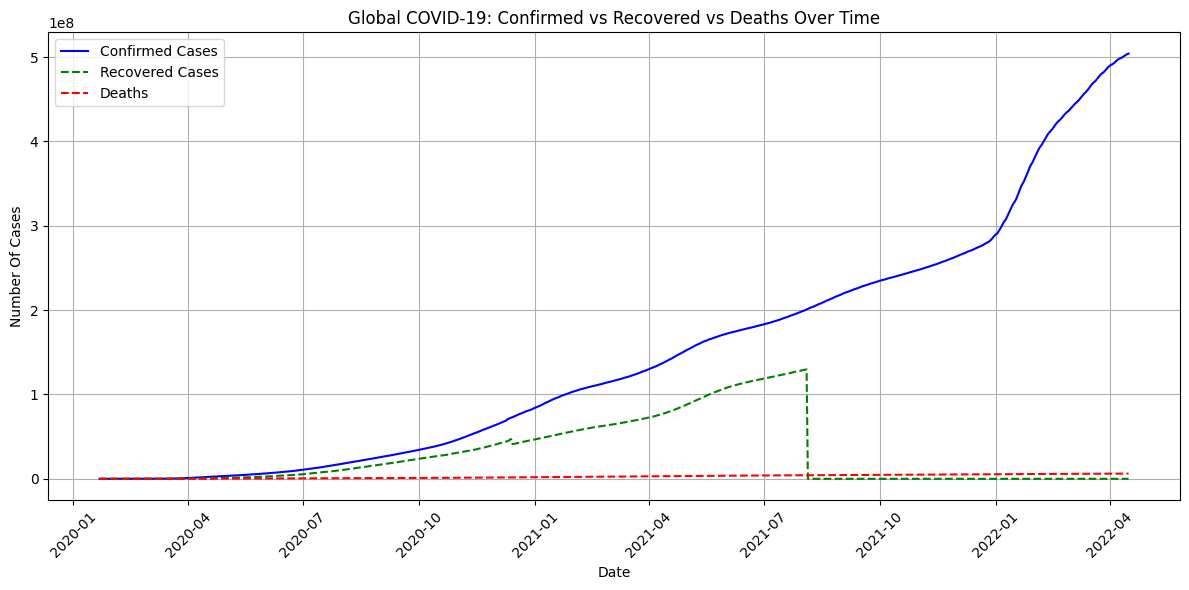

In [38]:
# Agregate globaly by date
global_df = df.groupby("Date")[["Confirmed", "Deaths", "Recovered"]].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(global_df["Date"], global_df["Confirmed"], label="Confirmed Cases", color="blue", linestyle="-")
plt.plot(global_df["Date"], global_df["Recovered"], label="Recovered Cases", color="green", linestyle="--")
plt.plot(global_df["Date"], global_df["Deaths"], label="Deaths", color="red", linestyle="--")

plt.xlabel("Date")
plt.ylabel("Number Of Cases")
plt.title("Global COVID-19: Confirmed vs Recovered vs Deaths Over Time")
plt.xticks(rotation=45)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Insight:
The chart shows a sustained rise in global confirmed COVID-19 cases over time, with deaths increasing at a much slower rate, indicating a relatively lower fatality proportion as the pandemic progressed. Recoveries grow steadily alongside confirmed cases, reflecting improvements in treatment and case management. The sharp drop observed in recovered cases in later periods likely reflects reporting or data consistency issues rather than an actual decline in recoveries.

#### 2. Daily New Cases Trend

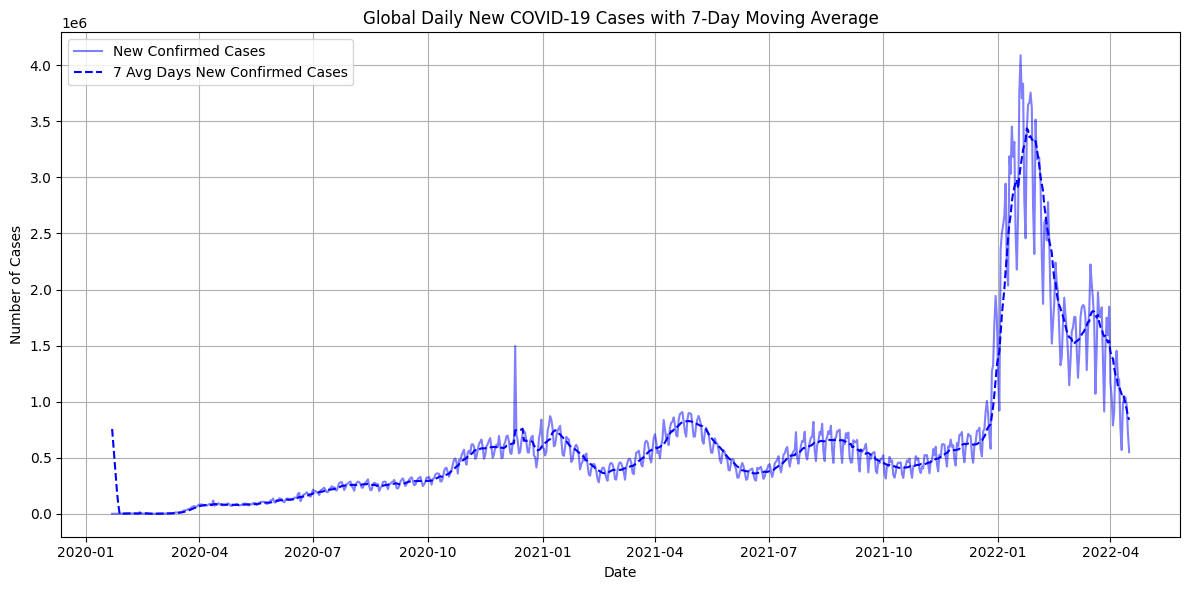

In [39]:
# Agregate the data for daily new cases
daily_df = df.groupby("Date")[["New_Confirmed", "New_Confirmed_Avg_7Days", "New_Recovered", "New_Deaths", "New_Recovered_Avg_7Days", "New_Deaths_Avg_7Days"]].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_df["Date"], daily_df["New_Confirmed"], label="New Confirmed Cases", color="blue", linestyle="-", alpha= 0.5)
plt.plot(daily_df["Date"], daily_df["New_Confirmed_Avg_7Days"], label="7 Avg Days New Confirmed Cases", color="blue", linestyle="--")

plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.title("Global Daily New COVID-19 Cases with 7-Day Moving Average")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Insight:
The daily new COVID-19 cases exhibit clear wave-like patterns over time, with multiple peaks corresponding to successive outbreak phases. The 7-day moving average smooths short-term reporting fluctuations and highlights the underlying trend, revealing a major surge in early 2022 followed by a gradual decline. This pattern reflects periodic resurgences driven by factors such as new variants, changes in mobility, and public health interventions.

#### 3. Daily Deaths vs Daily Recoveries

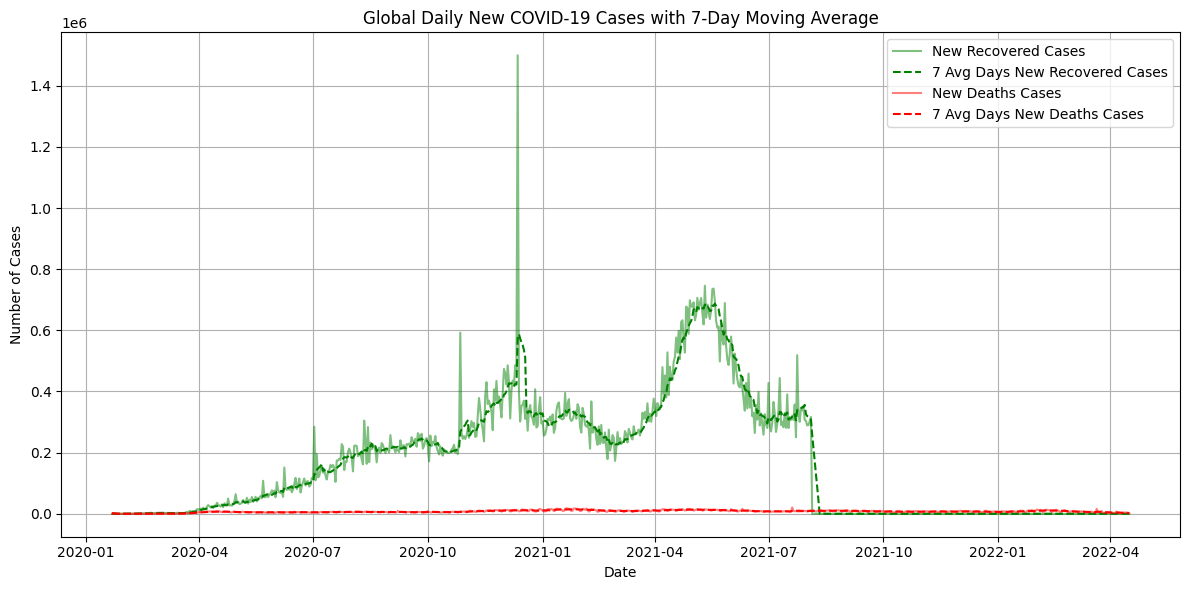

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(daily_df["Date"], daily_df["New_Recovered"], label="New Recovered Cases", color="green", linestyle="-", alpha= 0.5)
plt.plot(daily_df["Date"], daily_df["New_Recovered_Avg_7Days"], label="7 Avg Days New Recovered Cases", color="green", linestyle="--")
plt.plot(daily_df["Date"], daily_df["New_Deaths"], label="New Deaths Cases", color="red", linestyle="-", alpha= 0.5)
plt.plot(daily_df["Date"], daily_df["New_Deaths_Avg_7Days"], label="7 Avg Days New Deaths Cases", color="red", linestyle="--")

plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.title("Global Daily New COVID-19 Cases with 7-Day Moving Average")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Insight:
Daily recoveries largely mirror the wave patterns of COVID-19 infections, typically peaking after surges in new cases, which reflects the expected recovery lag. Daily deaths remain comparatively low and stable, suggesting improved clinical outcomes over time. Notably, after August 2021, recovery figures drop sharply due to recovery data no longer being updated, indicating a reporting limitation rather than an actual decline in recoveries.

### Country-Wise Comparative Visuals (with 100000 Confirmed cases)

In [41]:
eligible_countries = df.groupby("Country")["Confirmed"].max().loc[lambda x: x >= 100000].index

filtered_df = df[df["Country"].isin(eligible_countries)]
filtered_df["Country"].value_counts()

Country
Afghanistan           816
Albania               816
Algeria               816
Argentina             816
Armenia               816
                     ... 
Venezuela             816
Vietnam               816
West Bank and Gaza    816
Zambia                816
Zimbabwe              816
Name: count, Length: 123, dtype: int64

#### 4. Top 10 and Bottom 10 Countries by Total Confirmed Cases

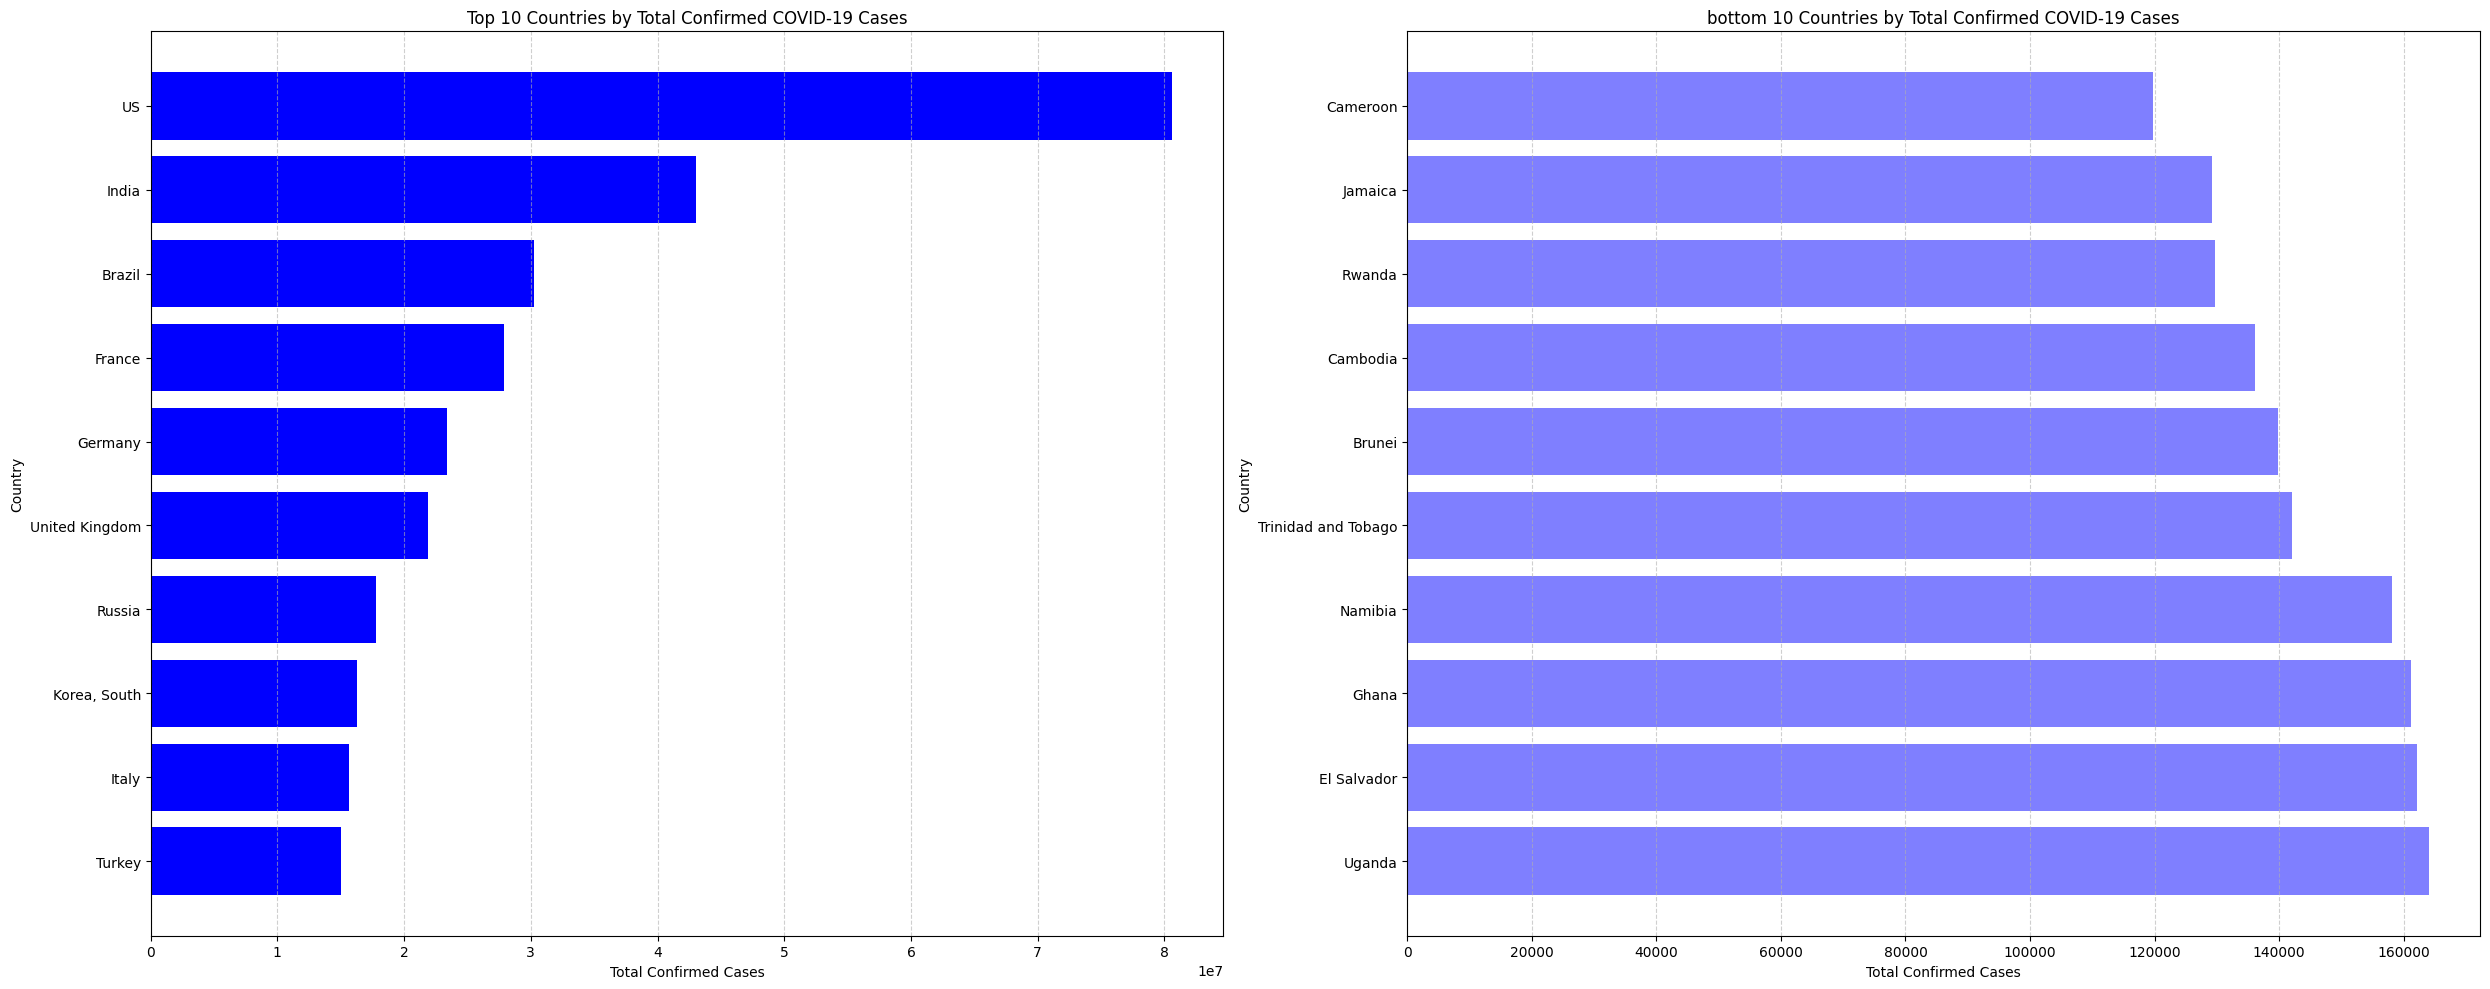

In [42]:
# Seperating top 10 and bottom 10 affected countries
top_10_df = filtered_df.groupby("Country")[["Confirmed", "Deaths", "Recovered"]].max().reset_index().sort_values(by="Confirmed", ascending=False).head(10)
bottom_10_df = filtered_df.groupby("Country")[["Confirmed", "Deaths", "Recovered"]].max().reset_index().sort_values(by="Confirmed", ascending=False).tail(10)

# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(25,10))

# top 10
axes[0].barh(top_10_df["Country"], top_10_df["Confirmed"], color="blue")
axes[0].set_xlabel("Total Confirmed Cases")
axes[0].set_ylabel("Country")
axes[0].set_title("Top 10 Countries by Total Confirmed COVID-19 Cases")
axes[0].invert_yaxis()
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

# bottom 10
axes[1].barh(bottom_10_df["Country"], bottom_10_df["Confirmed"], color="blue", alpha=0.5)
axes[1].set_xlabel("Total Confirmed Cases")
axes[1].set_ylabel("Country")
axes[1].set_title("bottom 10 Countries by Total Confirmed COVID-19 Cases")
axes[1].grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

##### Insight:
The chart highlights a stark disparity in COVID-19 burden across countries, focusing only on those with 100,000 or more confirmed cases to ensure meaningful comparison. A small number of countries, led by the United States, India, and Brazil, account for a disproportionately high number of cases, reflecting factors such as population size, testing capacity, and sustained transmission. In contrast, countries at the lower end of this filtered group report substantially fewer cases, which may also reflect differences in reporting and containment effectiveness.

#### 5. Top 10 Countries by Mortality Rate and Recovery Rate

In [43]:
# Calculating the mortality and recovery rate for aggregate data of country that had 1 lac or more confirmed cases
country_total_df = filtered_df.groupby("Country")[["Confirmed", "Deaths", "Recovered"]].max().reset_index()
country_total_df["Mortality_Rate"] = np.where(country_total_df["Confirmed"] > 0,
                               country_total_df["Deaths"]*100/country_total_df["Confirmed"], 0)
country_total_df["Recovery_Rate"] = np.where(country_total_df["Confirmed"] > 0,
                               country_total_df["Recovered"]*100/country_total_df["Confirmed"], 0)


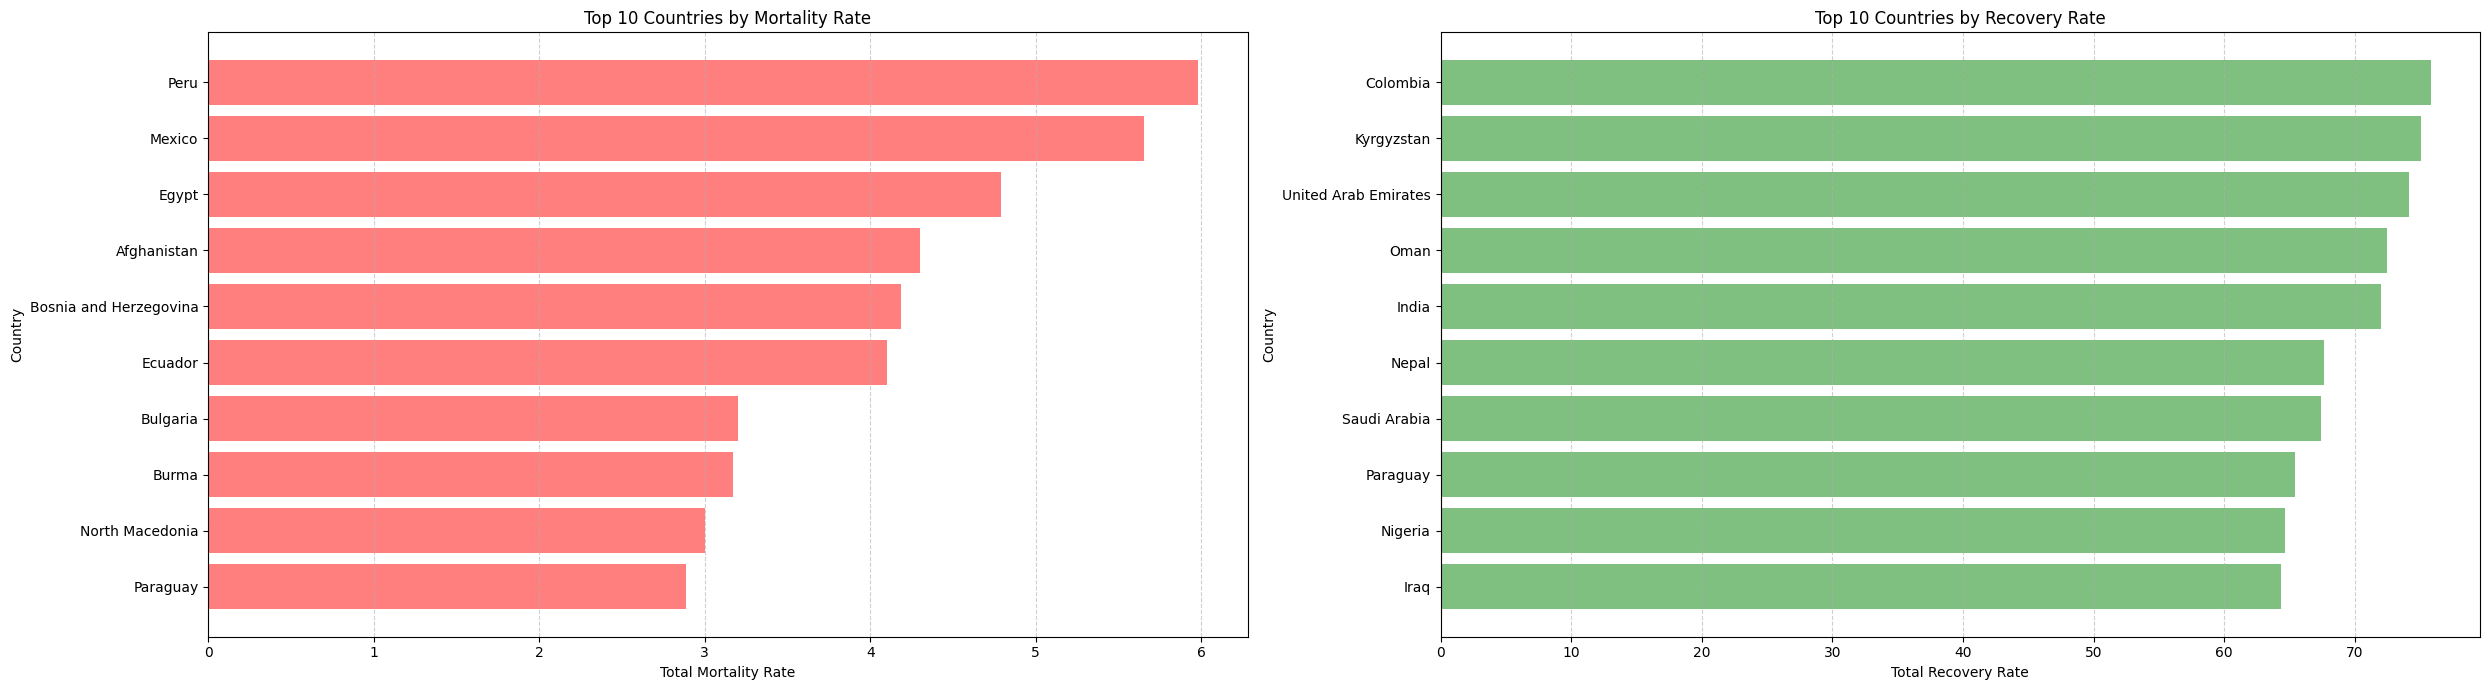

In [44]:
# Mortality rate (Top 10)
top_10_mortality = (
    country_total_df.groupby("Country")["Mortality_Rate"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

# Recovery rate (Top 10)
top_10_recovery = (
    country_total_df.groupby("Country")["Recovery_Rate"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)


# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(25,7))

# top 10 Mortality rate 
axes[0].barh(top_10_mortality.index, top_10_mortality.values, color="red", alpha= 0.5)
axes[0].set_xlabel("Total Mortality Rate")
axes[0].set_ylabel("Country")
axes[0].set_title("Top 10 Countries by Mortality Rate")
axes[0].invert_yaxis()
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

# top 10 recovery rate 
axes[1].barh(top_10_recovery.index, top_10_recovery.values, color="green", alpha= 0.5)
axes[1].set_xlabel("Total Recovery Rate")
axes[1].set_ylabel("Country")
axes[1].set_title("Top 10 Countries by Recovery Rate")
axes[1].invert_yaxis()
axes[1].grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


##### Insight:
This visualization compares the top 10 countries by COVID-19 mortality rate and recovery rate, using a filtered dataset that includes only countries with at least 100,000 confirmed cases to ensure reliable rate comparisons. Countries such as Peru and Mexico exhibit notably higher mortality rates, indicating a greater proportion of deaths among confirmed cases, while countries like Colombia, Kyrgyzstan, and the UAE show higher recovery rates, suggesting more favorable clinical outcomes or reporting practices.

It is important to note that global recovery data was not updated after August 2021, which may lead to inflated mortality rates or underestimated recovery rates for some countries in the later period. As a result, these recovery-related comparisons should be interpreted with caution, especially when contrasting countries affected by later waves of the pandemic.

#### 6. Bottom 10 Countries by Mortality Rate and Recovery Rate

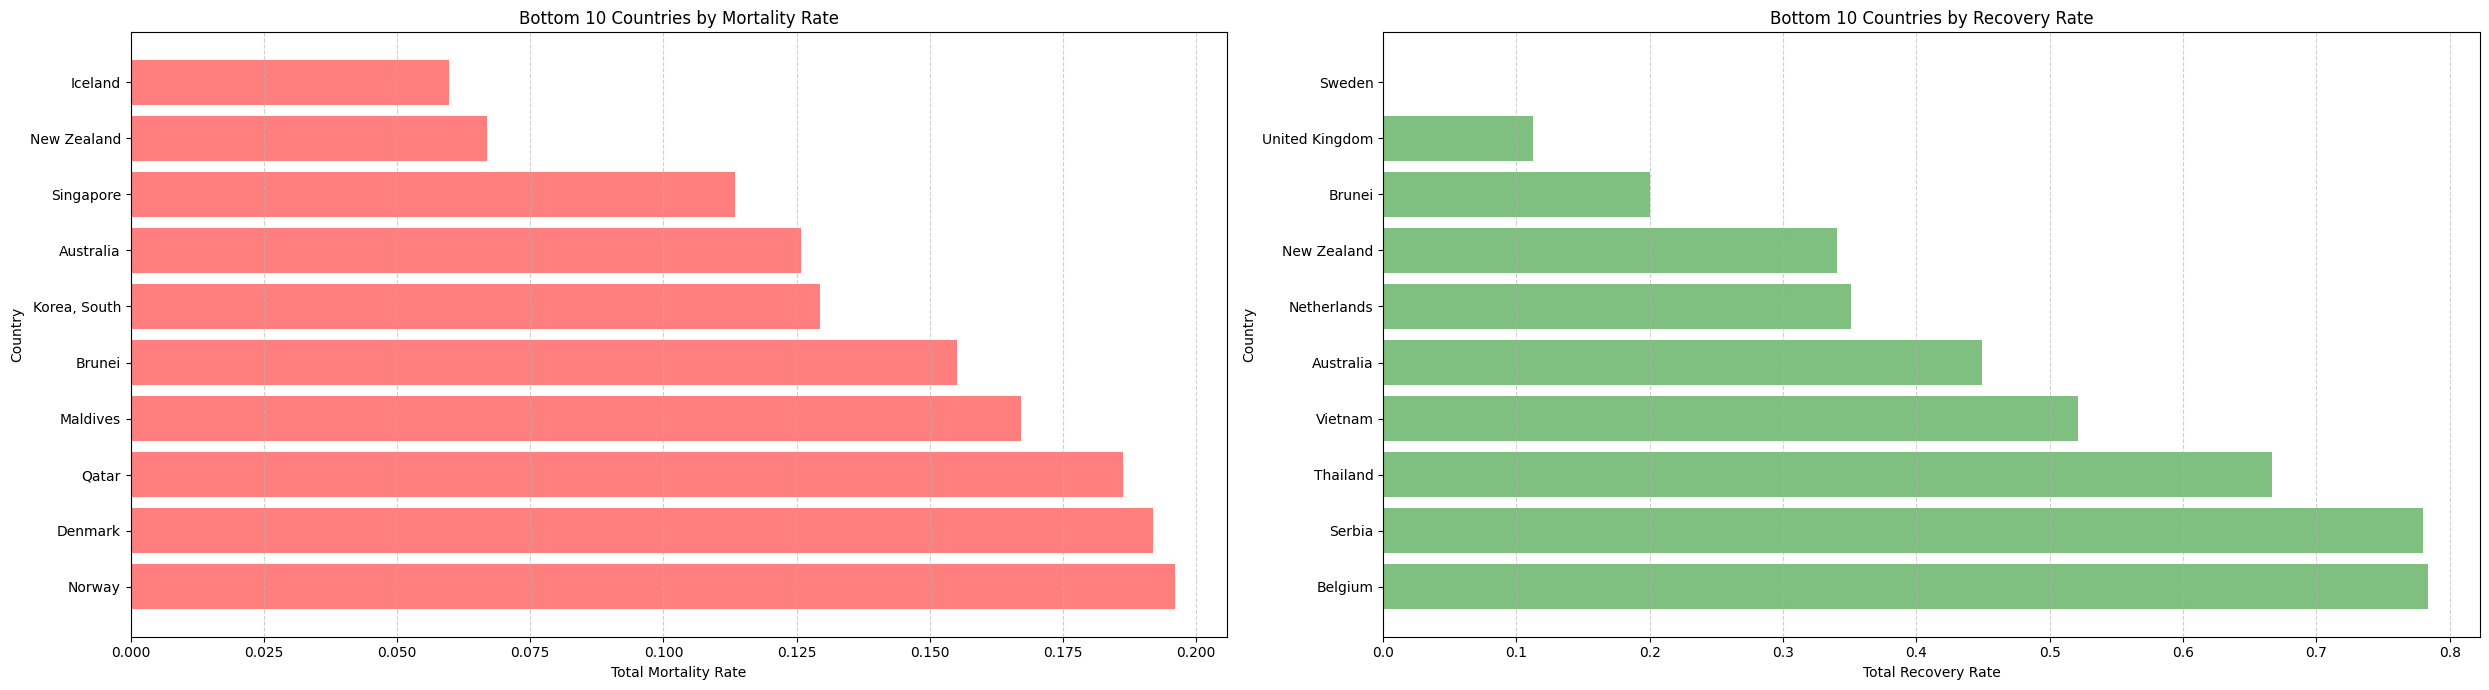

In [45]:
# Mortality rate (Top 10)
bottom_10_mortality = (
    country_total_df.groupby("Country")["Mortality_Rate"]
    .max()
    .sort_values(ascending=False)
    .tail(10)
)

# Recovery rate (Top 10)
bottom_10_recovery = (
    country_total_df.groupby("Country")["Recovery_Rate"]
    .max()
    .sort_values(ascending=False)
    .tail(10)
)


# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(25,7))

# top 10 Mortality rate 
axes[0].barh(bottom_10_mortality.index, bottom_10_mortality.values, color="red", alpha= 0.5)
axes[0].set_xlabel("Total Mortality Rate")
axes[0].set_ylabel("Country")
axes[0].set_title("Bottom 10 Countries by Mortality Rate")
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

# top 10 recovery rate 
axes[1].barh(bottom_10_recovery.index, bottom_10_recovery.values, color="green", alpha= 0.5)
axes[1].set_xlabel("Total Recovery Rate")
axes[1].set_ylabel("Country")
axes[1].set_title("Bottom 10 Countries by Recovery Rate")
axes[1].grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

##### Insight:
This visualization presents the bottom 10 countries by COVID-19 mortality rate and recovery rate, calculated using a filtered dataset that includes only countries with 100,000 or more confirmed cases to avoid distortions from very small case counts. Countries such as Iceland and New Zealand exhibit the lowest mortality rates, reflecting effective containment measures and healthcare responses, while countries like Sweden and the United Kingdom appear among the lowest recovery rates.

It is important to note that recovery data was not updated after August 2021, which may result in artificially lower recovery rates for several countries in the later stages of the pandemic. Consequently, recovery-rate comparisons—especially for countries affected by post-2021 waves should be interpreted with caution.

### Distribution & Spread Analysis

#### 7. Distribution of Daily New Cases

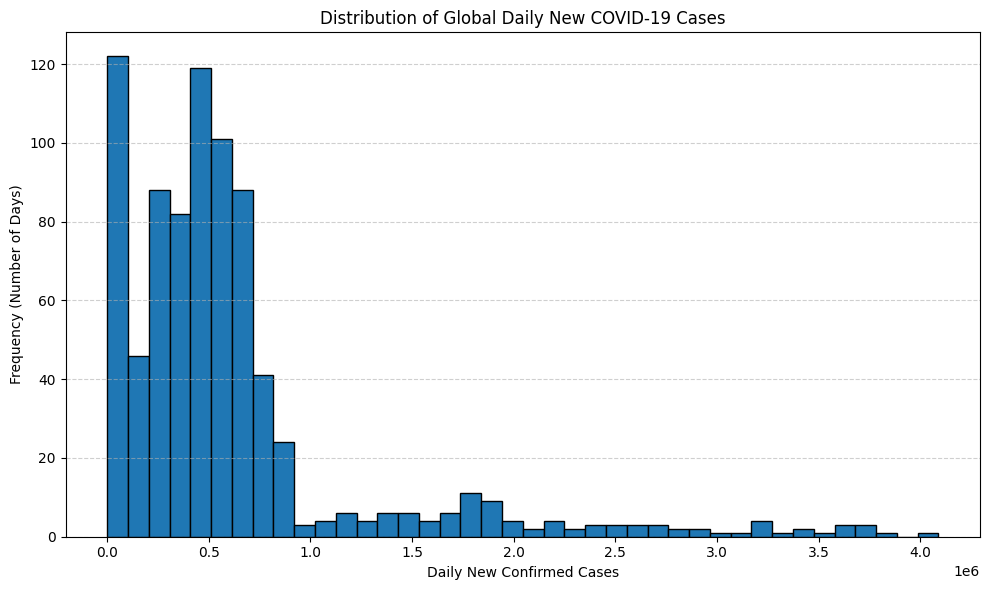

In [46]:
daily_cases = (
    df.groupby("Date")["New_Confirmed"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.hist(
    daily_cases["New_Confirmed"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("Daily New Confirmed Cases")
plt.ylabel("Frequency (Number of Days)")
plt.title("Distribution of Global Daily New COVID-19 Cases")

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


##### Insight:
The distribution of global daily new COVID-19 cases is highly right-skewed, indicating that for most days the number of new cases remained relatively low to moderate, while a smaller number of days experienced extreme surges. The long tail on the right reflects major outbreak waves most notably during late 2021 and early 2022 when daily cases reached unprecedented levels. This pattern highlights the pandemic’s wave-driven nature, where prolonged periods of manageable transmission were interrupted by short but intense spikes, often linked to new variants and changes in public health measures.

#### 8. Distribution of New Death and New Recovered Cases

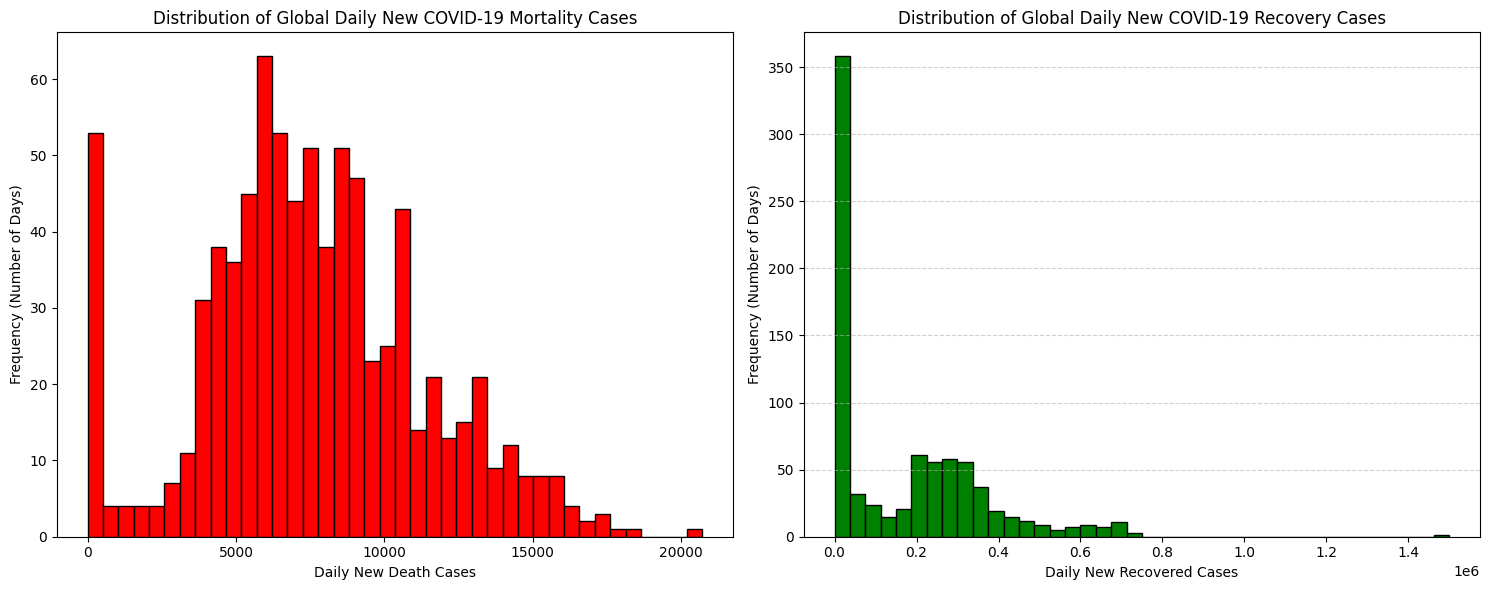

In [47]:
daily_cases_death = (
    df.groupby("Date")["New_Deaths"]
    .sum()
    .reset_index()
)

daily_cases_recovered = (
    df.groupby("Date")["New_Recovered"]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# New Deaths
axes[0].hist(
    daily_cases_death["New_Deaths"],
    bins=40,
    color="red",
    edgecolor="black"
)

axes[0].set_xlabel("Daily New Death Cases")
axes[0].set_ylabel("Frequency (Number of Days)")
axes[0].set_title("Distribution of Global Daily New COVID-19 Mortality Cases")

# New Recovered
axes[1].hist(
    daily_cases_recovered["New_Recovered"],
    bins=40,
    color="green",
    edgecolor="black"
)

axes[1].set_xlabel("Daily New Recovered Cases")
axes[1].set_ylabel("Frequency (Number of Days)")
axes[1].set_title("Distribution of Global Daily New COVID-19 Recovery Cases")

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

##### Insight:
The distribution of global daily new COVID-19 deaths shows a right-skewed pattern, with most days recording relatively moderate death counts and a smaller number of days experiencing sharp spikes during major pandemic waves. These peaks reflect periods of intense transmission and healthcare system strain.

In contrast, the distribution of daily recoveries is more irregular and heavily concentrated at lower values. This pattern should be interpreted with caution, as global recovery data was no longer consistently updated after August 2021. The apparent drop and clustering of recovery counts beyond this point are largely due to reporting gaps rather than an actual decline in recoveries.

### Relationship / Correlation Visuals

#### 9. Confirmed cases Vs Deaths Cases & Confirmed cases Vs Recovered Cases

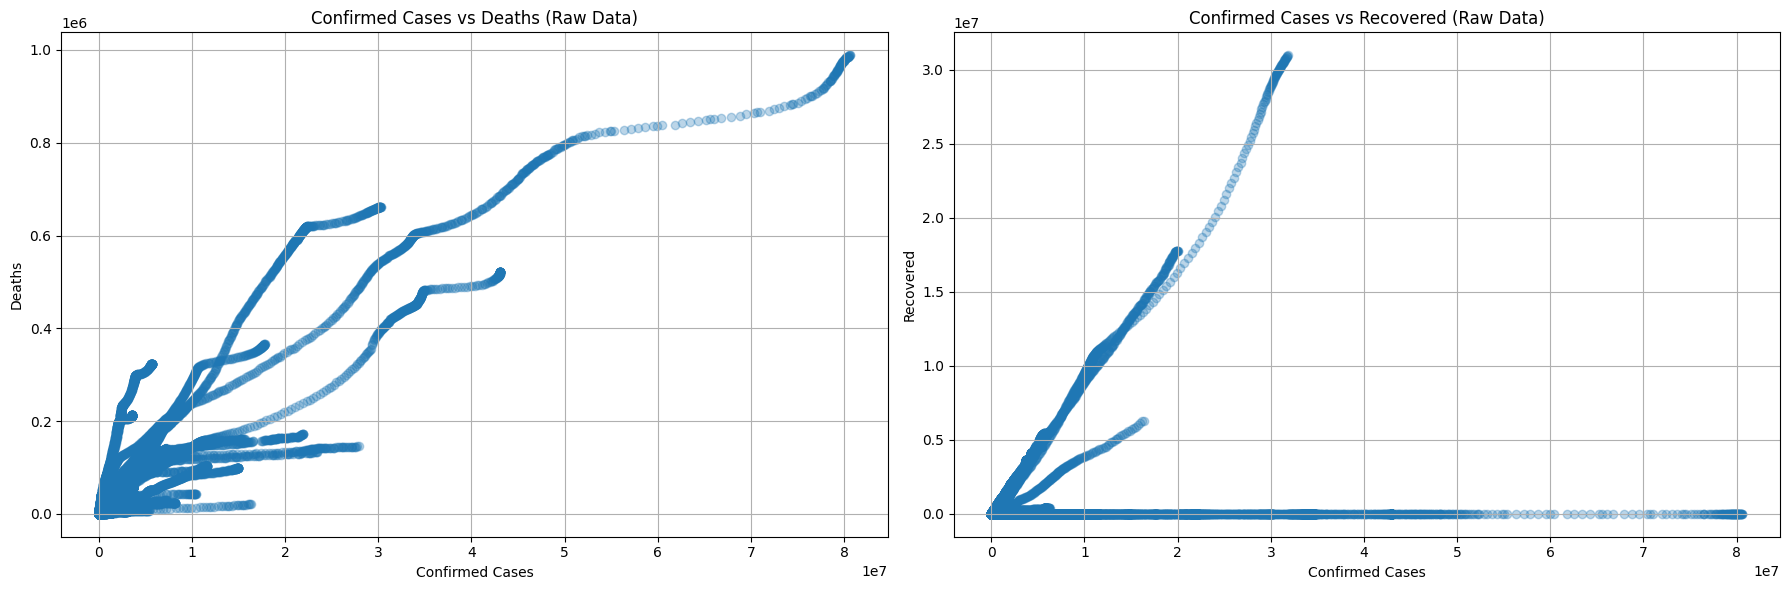

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ----------------------------------------
# 1. Confirmed vs Deaths
# ----------------------------------------
axes[0].scatter(
    df["Confirmed"],
    df["Deaths"],
    alpha=0.3
)
axes[0].set_title("Confirmed Cases vs Deaths (Raw Data)")
axes[0].set_xlabel("Confirmed Cases")
axes[0].set_ylabel("Deaths")
axes[0].grid(True)

# ----------------------------------------
# 2. Confirmed vs Recovered
# ----------------------------------------
axes[1].scatter(
    df["Confirmed"],
    df["Recovered"],
    alpha=0.3
)
axes[1].set_title("Confirmed Cases vs Recovered (Raw Data)")
axes[1].set_xlabel("Confirmed Cases")
axes[1].set_ylabel("Recovered")
axes[1].grid(True)

plt.tight_layout()
plt.show()


##### Insight:
The scatter plot of Confirmed Cases vs Deaths shows a strong positive relationship countries with higher confirmed case counts consistently report higher cumulative deaths. The curved and layered patterns reflect different national trajectories over time, influenced by factors such as population size, healthcare capacity, and the timing of pandemic waves.

In the Confirmed Cases vs Recovered plot, a similar positive relationship is visible for the period where recovery data is available, indicating that higher case counts were generally accompanied by higher recoveries. However, this relationship becomes distorted at higher confirmed case values because global recovery data was not consistently updated after August 2021. As a result, many later data points cluster near zero recoveries despite rising confirmed cases, which reflects reporting gaps rather than actual recovery trends.

#### 10. Active cases Vs Recovery_rate & Active cases Vs Mortality_rate

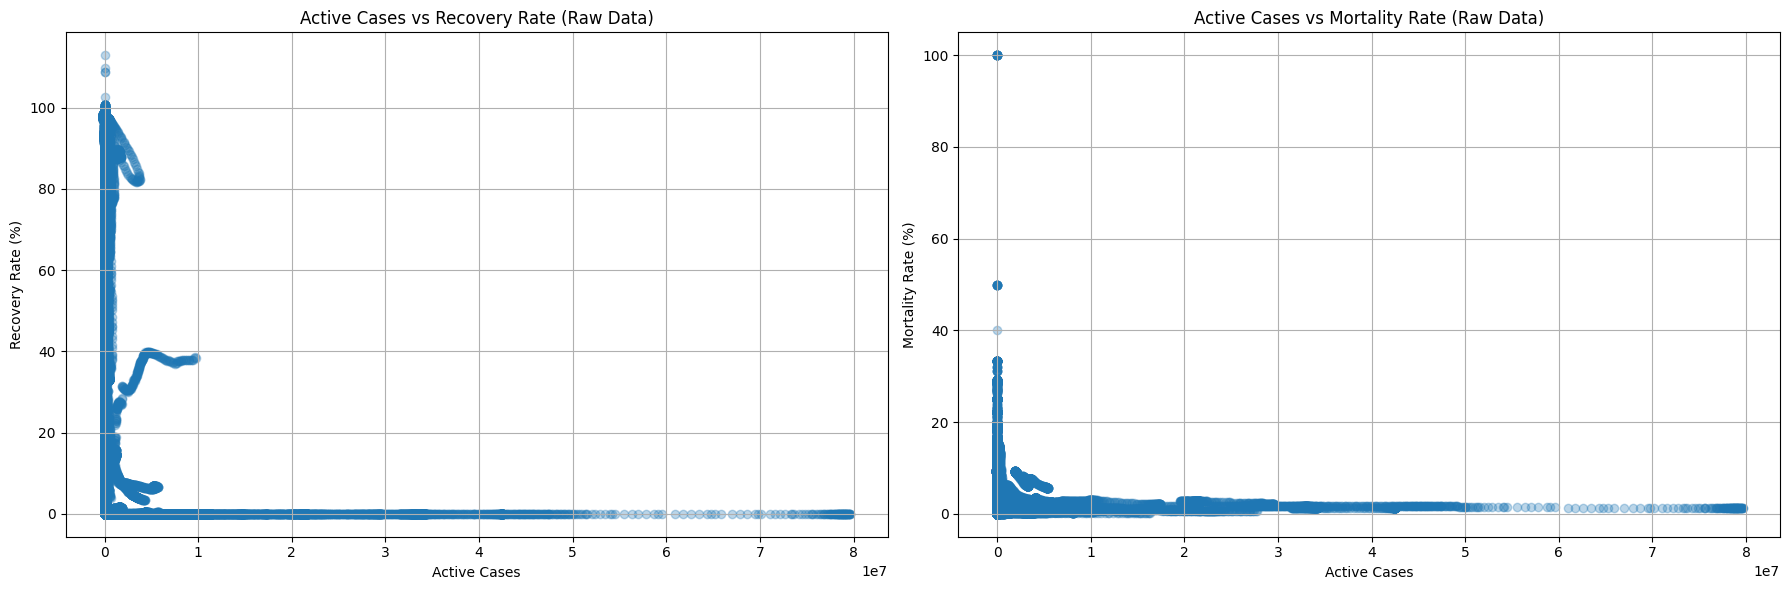

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ----------------------------------------
# 1. Active Cases vs Recovery Rate
# ----------------------------------------
axes[0].scatter(
    df["Active_Cases"],
    df["Recovery_Rate"],
    alpha=0.3
)
axes[0].set_title("Active Cases vs Recovery Rate (Raw Data)")
axes[0].set_xlabel("Active Cases")
axes[0].set_ylabel("Recovery Rate (%)")
axes[0].grid(True)

# ----------------------------------------
# 2. Active Cases vs Mortality Rate
# ----------------------------------------
axes[1].scatter(
    df["Active_Cases"],
    df["Mortality_Rate"],
    alpha=0.3
)
axes[1].set_title("Active Cases vs Mortality Rate (Raw Data)")
axes[1].set_xlabel("Active Cases")
axes[1].set_ylabel("Mortality Rate (%)")
axes[1].grid(True)

plt.tight_layout()
plt.show()


##### Insight:
The Active Cases vs Recovery Rate plot shows a highly scattered pattern with no clear linear relationship. Many observations cluster near 0% recovery rate, especially at higher active case counts. This pattern is largely driven by a data limitation global recovery figures were not consistently updated after August 2021. As a result, recovery rates appear artificially low for later periods, even when active cases are high, and should not be interpreted as actual declines in patient recovery.

In contrast, the Active Cases vs Mortality Rate plot shows that mortality rates are generally low and concentrated near the bottom of the scale as active cases increase. Extreme mortality values (close to 100%) occur only when active cases are very small, which typically reflects early-stage outbreaks or reporting anomalies rather than true lethality. Overall, the visualization suggests that rising active case counts do not proportionally increase mortality rates, while recovery-rate interpretations after 2021-08 must be treated with caution due to missing data.

#### 11. Correlation New Deaths VS New Recovered

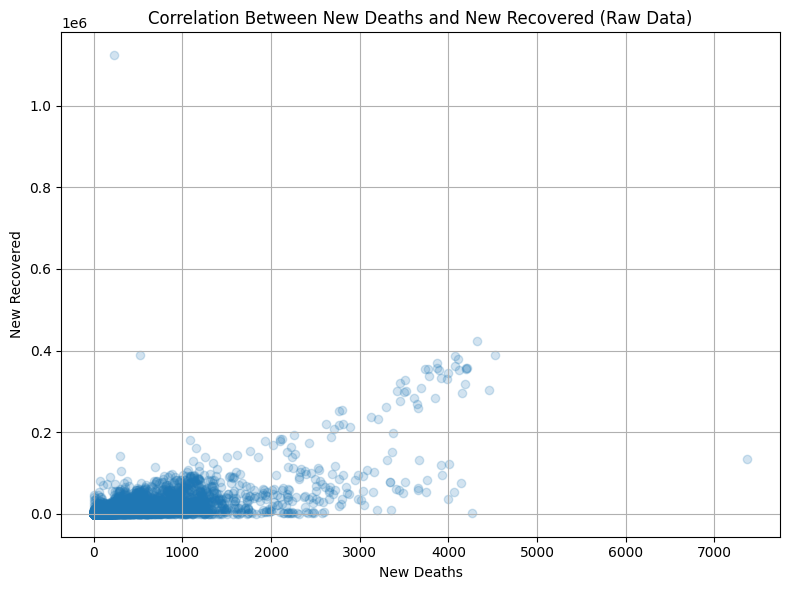

Pearson Correlation (Raw Data): 0.684


In [57]:
# Keep only meaningful values
corr_df = df[
    (df["New_Deaths"] > 0) &
    (df["New_Recovered"] > 0)
][["New_Deaths", "New_Recovered"]]


plt.figure(figsize=(8, 6))

plt.scatter(
    corr_df["New_Deaths"],
    corr_df["New_Recovered"],
    alpha=0.2
)

plt.xlabel("New Deaths")
plt.ylabel("New Recovered")
plt.title("Correlation Between New Deaths and New Recovered (Raw Data)")
plt.grid(True)
plt.tight_layout()
plt.show()


corr_value = corr_df["New_Deaths"].corr(corr_df["New_Recovered"])
print(f"Pearson Correlation (Raw Data): {corr_value:.3f}")


##### Insight:
The scatter plot indicates a weak-to-moderate positive relationship between new deaths and new recovies periods with higher deaths often coincide with higher recoveries, reflecting intense waves where overall case volumes were high and both outcomes increased simultaneously. However, the data is heavily clustered near zero, showing that most days experienced relatively low deaths and recoveries, with a few extreme outliers during peak waves.

It is important to note that global recovery data was not consistently updated after August 2021. This leads to many near-zero recovery values in the later period, which dampens the apparent correlation and may understate recovery counts relative to deaths. Therefore, correlation patterns observed after 2021-08 should be interpreted cautiously, as they are influenced by missing or incomplete recovery reporting rather than true epidemiological trends.

### Ratio & Severity Analysis

#### 12. Death-Recovery Ratio Over Time

In [50]:
# Date-wise aggregation
ratio_df = (
    df.groupby("Date")[["Deaths", "Recovered"]]
    .sum()
    .reset_index()
)

# Avoid division by zero
# Compute Death-Recovery Ratio
ratio_df["Death_Recovery_Ratio"] = np.where(ratio_df["Recovered"] > 0,
                                      ratio_df["Deaths"] / ratio_df["Recovered"],
                                      0)

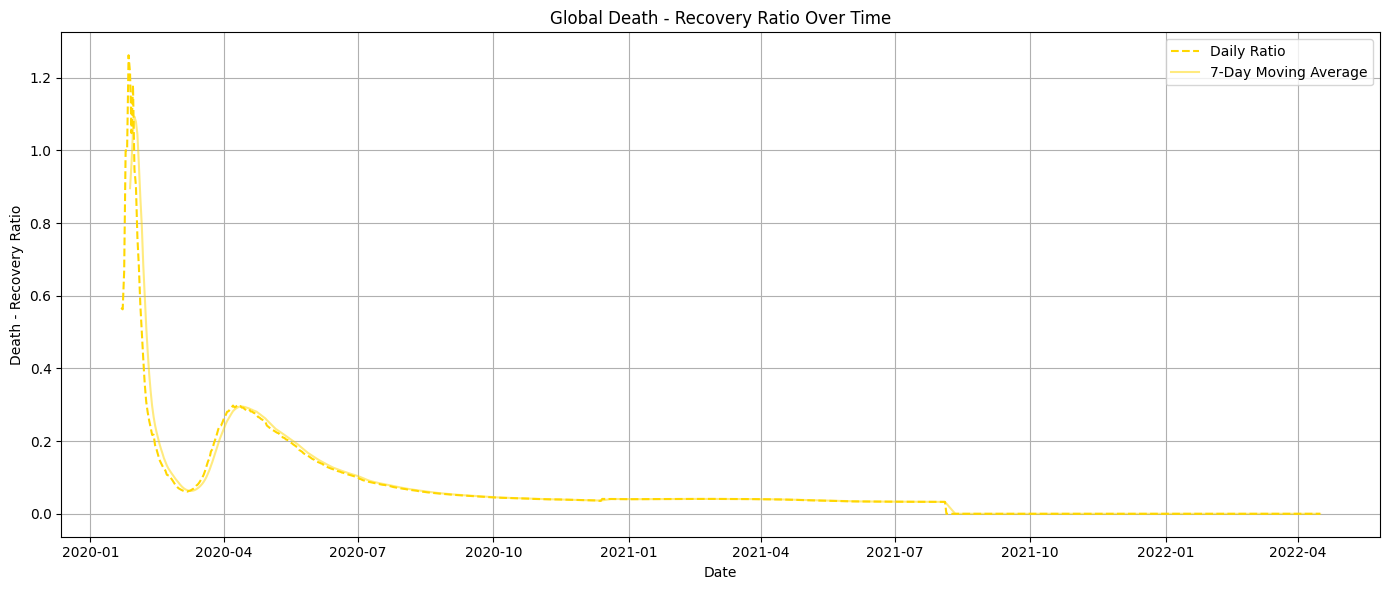

In [51]:
ratio_df["DR_Ratio_7Day_Avg"] = (
    ratio_df["Death_Recovery_Ratio"]
    .rolling(7)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    ratio_df["Date"],
    ratio_df["Death_Recovery_Ratio"],
    alpha=1,
    linestyle= "--",
    color= "gold",
    label="Daily Ratio"
)

plt.plot(
    ratio_df["Date"],
    ratio_df["DR_Ratio_7Day_Avg"],
    linestyle= "-",
    color="gold",
    alpha= 0.5,
    linewidth= 1.5,
    label="7-Day Moving Average"
)

plt.xlabel("Date")
plt.ylabel("Death - Recovery Ratio")
plt.title("Global Death - Recovery Ratio Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Insight:
The Death–Recovery Ratio shows a sharp spike in the early phase of the pandemic (early 2020), reflecting limited recoveries being reported while deaths began to rise an expected artifact of delayed recovery reporting and low initial case resolution. As the pandemic progressed through mid-2020, the ratio declined rapidly and stabilized, indicating that recoveries increasingly outpaced deaths as clinical management improved and case outcomes became clearer.

From late 2020 through mid-2021, the ratio remains consistently low, suggesting a relatively better global recovery-to-death balance despite multiple waves. However, after August 2021 the ratio collapses toward zero, not due to a true epidemiological shift, but because global recovery data was no longer consistently updated. As a result, the post 2021-08 segment of this chart should be interpreted with caution, as it primarily reflects data availability limitations rather than real-world improvements in survival outcomes.

#### 13. Growth Rate Trend

In [52]:
# Aggregate confirmed cases by date
growth_df = (
    df.groupby("Date")["Confirmed"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

# Compute daily growth rate
growth_df["Growth_Rate"] = growth_df["Confirmed"].pct_change()

# Remove first row (NaN growth)
growth_df = growth_df.dropna()


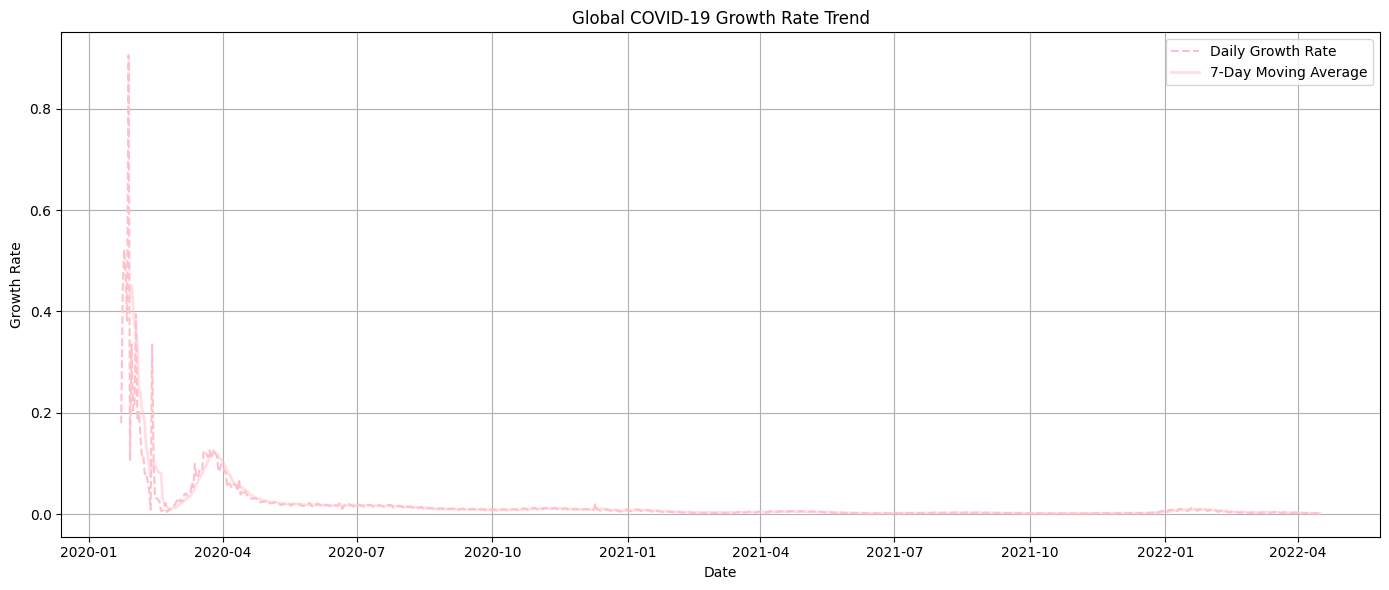

In [53]:
growth_df["Growth_Rate_7Day_Avg"] = (
    growth_df["Growth_Rate"]
    .rolling(7)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    growth_df["Date"],
    growth_df["Growth_Rate"],
    alpha=1,
    color= "pink",
    linestyle= "--",
    label="Daily Growth Rate"
)

plt.plot(
    growth_df["Date"],
    growth_df["Growth_Rate_7Day_Avg"],
    linewidth=2,
    color= "pink",
    alpha= 0.5,
    linestyle= "-",
    label="7-Day Moving Average"
)

plt.xlabel("Date")
plt.ylabel("Growth Rate")
plt.title("Global COVID-19 Growth Rate Trend")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Insight:
The global COVID-19 growth rate exhibits extreme volatility in the early months of 2020, with very high daily growth driven by a small initial case base and rapid global spread. As surveillance improved and case counts increased, the growth rate declined sharply and stabilized by mid-2020, indicating a transition from exponential expansion to more sustained transmission.

From late 2020 onward, the 7-day moving average remains consistently low, with only minor upticks during major waves (e.g., late 2020 and early 2022). These smaller increases reflect large absolute case surges occurring on top of an already high cumulative base rather than true exponential growth. Overall, the trend highlights how COVID-19 evolved from a rapidly emerging outbreak into a persistent, wave-driven pandemic with comparatively slower relative growth over time.

#### 14. Active vs Closed Cases Over Time

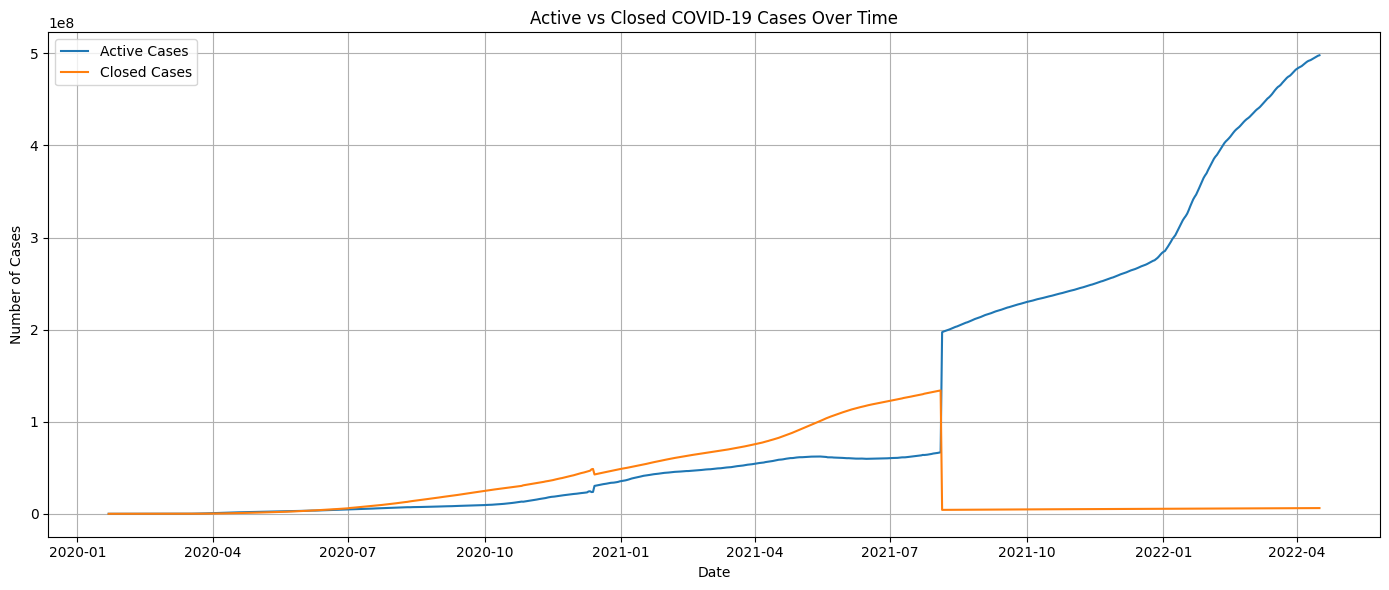

In [54]:
closed_df = (
    df.groupby("Date")[["Active_Cases", "Recovered", "Deaths"]]
    .sum()
    .reset_index()
)

closed_df["Closed_Cases"] = (
    closed_df["Recovered"] + closed_df["Deaths"]
)

plt.figure(figsize=(14, 6))

plt.plot(closed_df["Date"], closed_df["Active_Cases"], label="Active Cases")
plt.plot(closed_df["Date"], closed_df["Closed_Cases"], label="Closed Cases")

plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.title("Active vs Closed COVID-19 Cases Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Insight:
Early in the pandemic, closed cases (recoveries + deaths) steadily increased and closely tracked the rise in total infections, while active cases grew at a comparatively slower pace as many cases were being resolved. Through 2020 and the first half of 2021, this reflects a period where recoveries were being consistently reported and a growing share of cases transitioned from active to closed.

However, a clear structural break appears around August 2021, where closed cases drop sharply and remain artificially low thereafter. This is not an epidemiological shift, but a data reporting limitation i.e., global recovery data stopped being regularly updated after 2021-08. As a result, closed cases are significantly underestimated beyond this point, causing active cases to appear disproportionately high. Therefore, trends involving closed or active cases after August 2021 should be interpreted with caution, as they primarily reflect incomplete recovery reporting rather than true disease dynamics.

#### 15. Share of Active, Recovered & Deaths Over Time (Stacked Area)

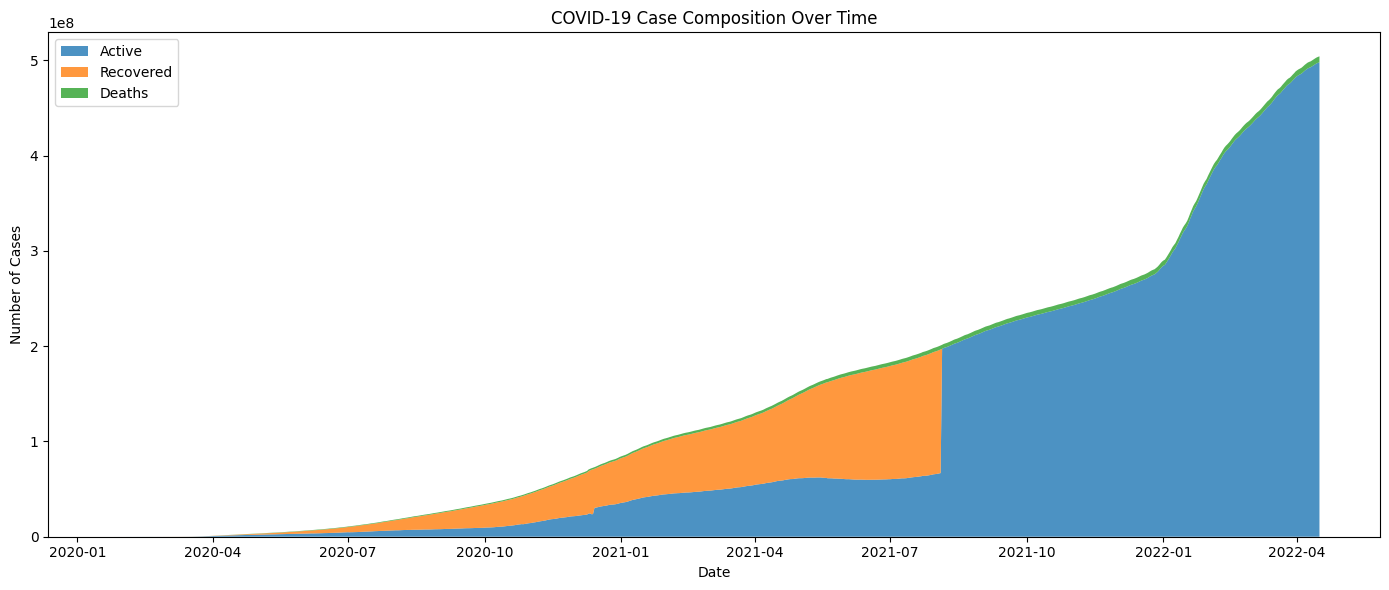

In [55]:
composition_df = (
    df.groupby("Date")[["Active_Cases", "Recovered", "Deaths"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.stackplot(
    composition_df["Date"],
    composition_df["Active_Cases"],
    composition_df["Recovered"],
    composition_df["Deaths"],
    labels=["Active", "Recovered", "Deaths"],
    alpha=0.8
)

plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.title("COVID-19 Case Composition Over Time")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


##### Insight:
This stacked area chart shows how global COVID-19 cases are distributed among active, recovered, and death categories over time. From early 2020 through mid-2021, recoveries make up a substantial and growing share of total cases, indicating that most infections were eventually resolved. Deaths remain a relatively small but steadily increasing component throughout the period.

A notable discontinuity appears around August 2021: the recovered segment abruptly stops growing, while active cases surge sharply. This shift is not epidemiological, but driven by missing global recovery data from 2021-08 onward. Because recoveries are no longer updated, new confirmed cases after this point are largely classified as active, inflating the active-case area and distorting the true case composition.

##### Closing Statement

This analysis explored global COVID-19 trends across cases, deaths, recoveries, growth rates, and case composition using multiple complementary visualizations. Together, the visuals highlight the rapid early spread of the virus, subsequent stabilization phases, and the shifting dynamics between active, recovered, and fatal cases over time. Patterns such as declining growth rates, evolving death–recovery relationships, and changing active case burdens reflect both epidemiological progression and improvements in response measures.

It is important to note that global recovery data was not consistently updated after August 2021, which impacts interpretations involving recovered, active, and closed cases in later periods. Additionally, for country-level analyses, only countries with at least 100,000 confirmed cases were included to ensure data reliability and reduce reporting noise. Despite these limitations, the combined visual evidence provides a coherent and data-driven overview of the pandemic’s global trajectory and its key structural trends.